<a href="https://colab.research.google.com/github/DrDourado/ME_615_Spring_2026/blob/main/ME_615_Non_Parametric_Classification_Spring_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Introduction to Non-Parametric Classification Models Tutorial

Welcome to this comprehensive tutorial on non-parametric classification models! In this notebook, we will delve into the fascinating world of machine learning algorithms that make fewer assumptions about the underlying data distribution, allowing them to capture complex patterns more flexibly than their parametric counterparts.

Our journey will cover the following key aspects:

1.  **Synthetic Dataset Generation**: We will begin by creating various synthetic datasets to illustrate different classification scenarios. This includes:
    *   A 2D binary classification dataset.
    *   A 2D multiclass classification dataset.
    *   A higher-dimensional (10-feature) binary classification dataset.

2.  **Implementation of Classification Models**: We will implement and apply several popular classification algorithms:
    *   **Logistic Regression**: A parametric model, included for comparative analysis as a baseline.
    *   **k-Nearest Neighbors (kNN)**: A non-parametric, instance-based learning algorithm.
    *   **Decision Trees**: A non-parametric model that partitions the feature space.
    *   **Random Forests**: An ensemble learning method based on Decision Trees, known for its robustness.

3.  **Visualization of Decision Boundaries**: A critical part of understanding these models is visualizing how they separate different classes. We will plot the decision boundaries for the 2D datasets to intuitively grasp their classification logic.

4.  **Key Concept Explanations**: Throughout the tutorial, we will explain important concepts relevant to each model:
    *   **Optimal 'k' for kNN**: Discussing methods to find the best number of neighbors.
    *   **Tree Pruning for Decision Trees**: Understanding how to prevent overfitting in Decision Trees.
    *   **Ensemble Learning for Random Forests**: Exploring the power of combining multiple models.
    *   **Principal Component Analysis (PCA)**: Applying PCA for dimensionality reduction to visualize decision boundaries in higher-dimensional feature spaces.

By the end of this tutorial, you will have a clear understanding of how non-parametric classifiers work, their strengths and weaknesses, and how to implement and visualize them using Python's scikit-learn library.

## 2D Binary Classification

Generate a synthetic 2D binary classification dataset using `sklearn.datasets.make_classification`.

This data will be used to illustrate the basic concepts and model behaviors.

In [1]:
from sklearn.datasets import make_classification

# Generate a synthetic 2D binary classification dataset
X_2d_binary, y_2d_binary = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=2,
    random_state=42
)

# Print the shape of the generated dataset
print(f"Shape of X_2d_binary: {X_2d_binary.shape}")
print(f"Shape of y_2d_binary: {y_2d_binary.shape}")

Shape of X_2d_binary: (200, 2)
Shape of y_2d_binary: (200,)


## Classifier: Logistic Regression

Logistic Regression is a fundamental classification algorithm, often used as a baseline, despite its name suggesting 'regression'. It's a **parametric model** because it assumes a specific functional form for the relationship between the input features and the probability of the output class.

1.  **Modeling Probabilities with the Sigmoid Function**: Instead of directly predicting the class, Logistic Regression models the probability that a given input belongs to a particular class. It does this by applying the **sigmoid function** (also known as the logistic function) to a linear combination of the input features. The sigmoid function, defined as `σ(z) = 1 / (1 + e^(-z))`, maps any real-valued number into a probability between 0 and 1. Here, `z` is the linear combination of features: `z = β₀ + β₁x₁ + ... + βₚxₚ`.

    *   If `σ(z)` is greater than a certain threshold (commonly 0.5), the input is classified into one class; otherwise, it's classified into the other.

2.  **Characteristic Linear Decision Boundary**: A key characteristic of Logistic Regression is its **linear decision boundary**. Because the sigmoid function transforms a linear combination of features, the point where the probability crosses the classification threshold (e.g., 0.5) corresponds to `z = 0`. This `z = 0` equation (`β₀ + β₁x₁ + ... + βₚxₚ = 0`) defines a hyperplane (a line in 2D, a plane in 3D) that separates the classes. This means Logistic Regression can only effectively separate data that is linearly separable.

3.  **Parametric Nature**: As a parametric model, Logistic Regression estimates a fixed set of parameters (the `β` coefficients) from the training data. These parameters define the shape and position of the linear decision boundary. It makes an assumption about the distribution of the data (e.g., that the log-odds of the outcome is a linear function of the features). This can be a strength when the assumption holds, leading to efficient and interpretable models, but a limitation when the underlying relationship is non-linear, as it might struggle to capture complex patterns.

In [2]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# Helper function to plot decision boundaries
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    # Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    h = 0.02  # step size in the mesh

    # Generate a meshgrid of points
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict class for each point in the meshgrid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the contour of the decision boundary
    plt.contourf(xx, yy, Z, alpha=0.8)

    # Plot the training points
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', s=50, cmap=plt.cm.RdYlBu)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.colorbar(label='Class')
    plt.show()

# Helper function to automatically save generated figures (credit to Aurelien Geron "Hands-On Machine Learning with Scikit-Learn & Tensorflow")
ROOT_DIR = "."
IMAGES_PATH = os.path.join(ROOT_DIR, "images")
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [4]:
# Instantiating and fitting a Logistic Regression model
log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_2d_binary, y_2d_binary)

print("Logistic Regression model fitted successfully.")

Logistic Regression model fitted successfully.


In [5]:
# Visualizing Classification Performance
y_pred_log_reg = log_reg_model.predict(X_2d_binary)

print("Classification Report for Logistic Regression:")
print(classification_report(y_2d_binary,y_pred_log_reg))

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.88      0.85      0.86       100
           1       0.85      0.88      0.87       100

    accuracy                           0.86       200
   macro avg       0.87      0.86      0.86       200
weighted avg       0.87      0.86      0.86       200



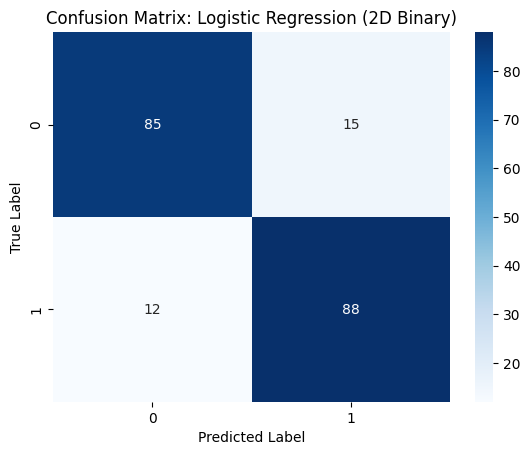

Saving figure confusion_matrix_logistic_regression_2d_binary


<Figure size 640x480 with 0 Axes>

In [6]:
# Plotting Classifier Confusion Matrix
conf_matrix_log_reg = confusion_matrix(y_2d_binary,y_pred_log_reg)

sns.heatmap(conf_matrix_log_reg, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Logistic Regression (2D Binary)")
plt.show()
save_fig("confusion_matrix_logistic_regression_2d_binary")

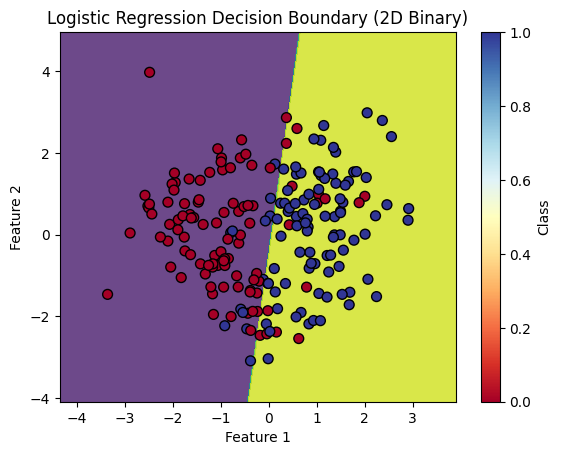

Saving figure decision_boundary_logistic_regression_2d_binary


<Figure size 640x480 with 0 Axes>

In [7]:
# Call the decision boundary plotting function for Logistic Regression
plot_decision_boundary(log_reg_model, X_2d_binary, y_2d_binary, title='Logistic Regression Decision Boundary (2D Binary)')
save_fig("decision_boundary_logistic_regression_2d_binary")

## Classifier: k-Nearest Neighbors (kNN)

k-Nearest Neighbors (kNN) is a simple, non-parametric, instance-based learning algorithm that can be used for both classification and regression tasks. Unlike parametric models that learn a function from the training data, kNN simply memorizes the training dataset. When it comes to making a prediction for a new data point, it looks at its 'neighbors'.

1.  **How kNN Classifies Data Points**:
    *   For a given new data point, kNN calculates the distance between this new point and all other points in the training dataset. Common distance metrics include Euclidean distance, Manhattan distance, or Minkowski distance.
    *   It then identifies the `k` nearest data points (neighbors) to the new point.
    *   For classification, the new data point is assigned to the class that is most frequent among its `k` nearest neighbors. In essence, it's a 'majority vote' among the neighbors.

2.  **Non-Parametric Nature**:
    *   kNN is considered non-parametric because it makes no explicit assumptions about the functional form of the mapping from inputs to outputs. It does not learn any parameters during training that define a decision boundary in the same way Logistic Regression does. Instead, its decision boundary is implicitly defined by the entire training dataset.

3.  **The Role of the 'k' Parameter and its Influence on Bias and Variance**:
    *   The `k` in kNN refers to the number of neighbors considered when making a prediction. The choice of `k` is crucial and significantly impacts the model's performance:
        *   **Small `k` (e.g., `k=3`)**: A very small `k` makes the model highly sensitive to noise in the training data. This can lead to a highly complex decision boundary, high variance (overfitting), and lower bias. The model might fit the training data very closely but generalize poorly to unseen data.
        *   **Large `k`**: A large `k` makes the model smoother and less sensitive to individual noisy points. This tends to reduce variance (underfitting) but increases bias. The decision boundary becomes simpler, and the model might overlook local patterns, potentially leading to lower accuracy on both training and test data.
    *   The goal is to find an optimal `k` that balances bias and variance, leading to good generalization performance.

### Determining Optimal 'k' with the 'Elbow Plot'

An 'Elbow Plot' is a common heuristic used to help determine an appropriate value for `k` in kNN (or the number of clusters in K-Means clustering).

1.  **Purpose of the Elbow Plot**: The plot illustrates how a performance metric (like accuracy or error rate) changes as `k` varies. By plotting accuracy against different `k` values, we can visually identify a `k` where the improvement in accuracy starts to diminish significantly, forming an 'elbow' shape.

2.  **Interpreting the Plot**:
    *   As `k` increases from 1, initially, accuracy often improves as the model becomes more robust to noise (moving from high variance to lower variance).
    *   However, if `k` continues to increase, the model might start to oversimplify the decision boundary, increasing bias and leading to a decrease in accuracy. This is where the 'elbow' might appear.
    *   The optimal `k` is usually chosen at the point where the accuracy is high and stable, and further increases in `k` do not yield substantial improvements or even lead to a decline. This point represents a good balance between bias (model too simple) and variance (model too complex), helping to prevent both underfitting and overfitting.

Calculated accuracies for k from 3 to 29.


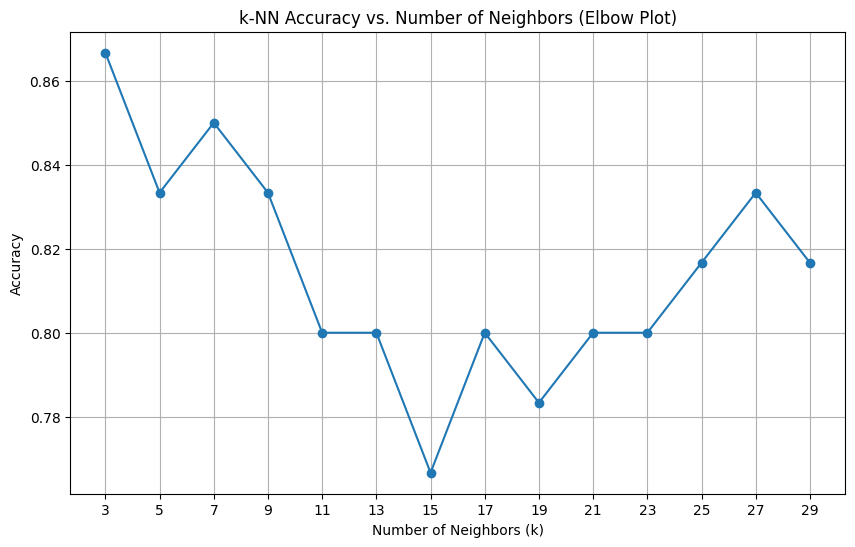

Saving figure elbow_plot_knn_2d_binary


<Figure size 640x480 with 0 Axes>

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split the X_2d_binary and y_2d_binary data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_2d_binary, y_2d_binary, test_size=0.3, random_state=42)

accuracies = []
k_range = range(3, 31, 2) # Iterate k from 3 to 30

for k in k_range:
    # Instantiate a KNeighborsClassifier model with the current k value
    knn_k_model = KNeighborsClassifier(n_neighbors=k)

    # Train this model on the training data
    knn_k_model.fit(X_train, y_train)

    # Predict on the test data
    y_pred = knn_k_model.predict(X_test)

    # Calculate the accuracy score on the predictions
    accuracy = accuracy_score(y_test, y_pred)

    # Store the accuracy
    accuracies.append(accuracy)

print(f"Calculated accuracies for k from 3 to {max(k_range)}.")

# Plot the calculated accuracy scores against their respective k values
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o', linestyle='-')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('k-NN Accuracy vs. Number of Neighbors (Elbow Plot)')
plt.xticks(list(k_range))
plt.grid(True)
plt.show()
save_fig("elbow_plot_knn_2d_binary")

In [9]:
# Instantiating a KNeighborsClassifier model with an "optimal" n_neighbors value
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_2d_binary, y_2d_binary)

print("k-Nearest Neighbors model (k=5) fitted successfully.")

k-Nearest Neighbors model (k=5) fitted successfully.


In [10]:
# Visualizing Classifier Performance
y_pred_knn = knn_model.predict(X_2d_binary)

print("Classification Report for kNN:")
print(classification_report(y_2d_binary,y_pred_knn))

Classification Report for kNN:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       100
           1       0.91      0.91      0.91       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200



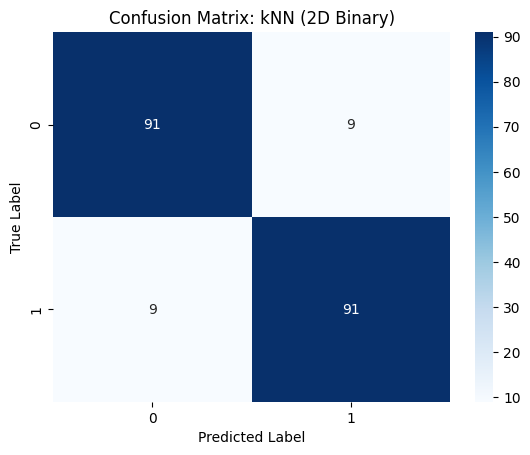

Saving figure confusion_matrix_knn_2d_binary


<Figure size 640x480 with 0 Axes>

In [11]:
# Plotting Classifier Confusion Matrix
conf_matrix_knn = confusion_matrix(y_2d_binary,y_pred_knn)

sns.heatmap(conf_matrix_knn, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: kNN (2D Binary)")
plt.show()
save_fig("confusion_matrix_knn_2d_binary")

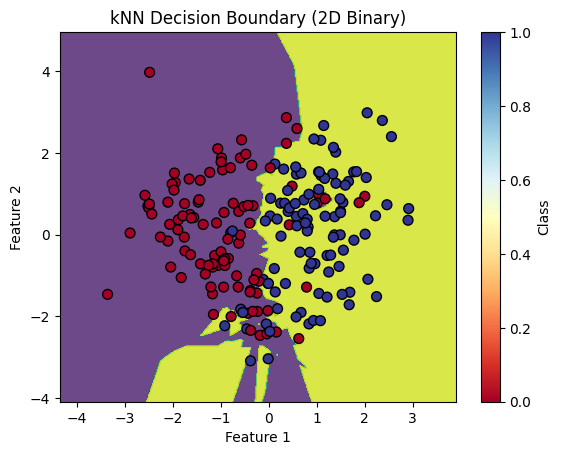

Saving figure decision_boundary_knn_2d_binary


<Figure size 640x480 with 0 Axes>

In [12]:
# Call the decision boundary plotting function for Logistic Regression
plot_decision_boundary(knn_model, X_2d_binary, y_2d_binary, title='kNN Decision Boundary (2D Binary)')
save_fig("decision_boundary_knn_2d_binary")

## Classifier: Decision Tree

Decision Trees are powerful, non-parametric supervised learning algorithms used for both classification and regression tasks. They work by partitioning the feature space into a set of rectangles (or hyper-rectangles in higher dimensions) and then fitting a simple model (like a constant or class label) in each region. The model is essentially a tree-like structure of decisions.

1.  **How Decision Trees Classify Data Points**:
    *   A Decision Tree classifies an input by navigating through a series of if-else conditions (decisions) based on its feature values. Each internal node of the tree represents a "test" on an attribute (e.g., "Is feature 1 > 0.5?"), each branch represents the outcome of the test, and each leaf node represents a class label (or a value in regression).
    *   The process starts at the root node and follows the path down to a leaf node, which provides the prediction.

2.  **Non-Parametric Nature**:
    *   Decision Trees are non-parametric because they do not make assumptions about the underlying distribution of the data. Instead, they learn the structure from the data itself. Their decision boundaries are typically orthogonal to the feature axes (axis-aligned splits), forming rectangular regions.

3.  **Key Concepts: Impurity and Splitting Criteria**:
    *   The core idea behind building a Decision Tree is to find the "best" splits that effectively separate the classes. "Best" is typically defined by a metric that measures the **impurity** or heterogeneity of a node.
    *   **Impurity Measures**:
        *   **Gini Impurity**: For a node, Gini impurity measures the probability of incorrectly classifying a randomly chosen element in the dataset if it were randomly labeled according to the class distribution in that node. `Gini = 1 - Σ (p_i)^2`, where `p_i` is the proportion of samples belonging to class `i` at the node. The Gini impurity takes values between 0 and 0.5. A value of 0 indicates that the node is pure (i.e., all elements belong to the same class), while a value of 0.5 indicates maximum impurity (i.e., an equal distribution of classes). When constructing a decision tree, the algorithm searches for the feature and the threshold that minimizes the weighted sum of the Gini impurities of the resulting child nodes. By recursively splitting the data based on features and thresholds, the decision tree aims to create nodes with increasingly pure subsets of data until a stopping criterion is met.
        *   **Entropy**: Entropy, from information theory, measures the average amount of information needed to identify the class of a randomly chosen instance in the node. `Entropy = - Σ p_i * log2(p_i)`. The entropy takes values between 0 and 1. A value of 0 indicates that the node is pure (i.e., all elements belong to the same class), while a value of 1 indicates maximum impurity (i.e., an equal distribution of classes). The algorithm searches for the feature and the threshold that minimizes the weighted sum of the entropies of the resulting child nodes.
    *   **Splitting Criteria**: During tree construction, the algorithm evaluates various possible splits for each feature and selects the split that results in the greatest reduction in impurity (or the greatest "information gain"). This recursive process continues until a stopping criterion is met (e.g., all nodes are pure, or `max_depth` is reached).

4.  **Tree Pruning and Overfitting**:
    *   A Decision Tree that is grown to its full extent (i.e., until all leaves are pure or a minimum number of samples per leaf is met) can become very complex and highly specific to the training data. This often leads to **overfitting**, where the model performs exceptionally well on the training data but poorly on unseen test data.
    *   **Tree pruning** is a technique used to reduce the complexity of the tree and prevent overfitting. Common pruning techniques include:
        *   **Pre-pruning (Early Stopping)**: Stopping the tree growth early by setting constraints during the tree construction. Examples of such hyperparameters include:
            *   `max_depth`: Limits the maximum depth of the tree. As seen in the visualizations, a shallower tree (smaller `max_depth`) results in smoother, simpler decision boundaries, reducing complexity and potential overfitting.
            *   `min_samples_split`: The minimum number of samples required to split an internal node.
            *   `min_samples_leaf`: The minimum number of samples required to be at a leaf node.
        *   **Post-pruning**: Growing the full tree first and then removing (pruning) branches that do not contribute significantly to predictive accuracy on a validation set.

    *   By limiting the tree's complexity through pruning, we aim to find a balance between bias and variance, leading to better generalization performance on new data. The visualizations clearly demonstrate how a default, unpruned tree can create very intricate, jagged boundaries that might capture noise, while a pruned tree creates simpler, more generalizable boundaries.

In [13]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate an unpruned DecisionTreeClassifier model and fit it
dtree_model = DecisionTreeClassifier(random_state=42)
dtree_model.fit(X_2d_binary, y_2d_binary)

print("Default Decision Tree model fitted successfully.")

Default Decision Tree model fitted successfully.


In [14]:
# Visualizing Classifier Performance
y_pred_dtree = dtree_model.predict(X_2d_binary)

print("Classification Report for Decision Tree:")
print(classification_report(y_2d_binary,y_pred_dtree))

Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



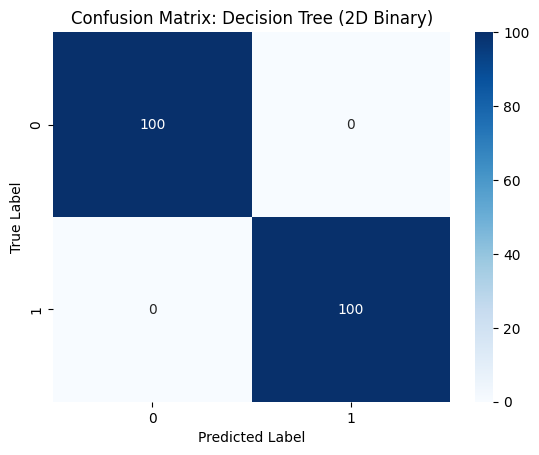

Saving figure confusion_matrix_dtree_2d_binary


<Figure size 640x480 with 0 Axes>

In [15]:
# Plotting Classifier Confusion Matrix
conf_matrix_dtree = confusion_matrix(y_2d_binary,y_pred_dtree)

sns.heatmap(conf_matrix_dtree, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Decision Tree (2D Binary)")
plt.show()
save_fig("confusion_matrix_dtree_2d_binary")

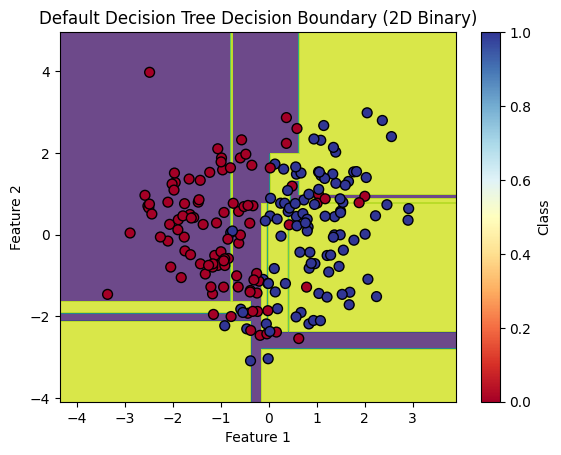

Saving figure decision_boundary_dtree_2d_binary


<Figure size 640x480 with 0 Axes>

In [16]:
# Call the decision boundary plotting function for the default Decision Tree model
plot_decision_boundary(dtree_model, X_2d_binary, y_2d_binary, title='Default Decision Tree Decision Boundary (2D Binary)')
save_fig("decision_boundary_dtree_2d_binary")

In [17]:
# Instantiate a second DecisionTreeClassifier with a limited max_depth (pruning)
dtree_pruned_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dtree_pruned_model.fit(X_2d_binary, y_2d_binary)

print("Pruned Decision Tree model (max_depth=3) fitted successfully.")

Pruned Decision Tree model (max_depth=3) fitted successfully.


In [18]:
# Visualizing Classifier Performance
y_pred_dtree_pruned = dtree_pruned_model.predict(X_2d_binary)

print("Classification Report for Decision Tree Pruned:")
print(classification_report(y_2d_binary,y_pred_dtree_pruned))

Classification Report for Decision Tree Pruned:
              precision    recall  f1-score   support

           0       0.98      0.84      0.90       100
           1       0.86      0.98      0.92       100

    accuracy                           0.91       200
   macro avg       0.92      0.91      0.91       200
weighted avg       0.92      0.91      0.91       200



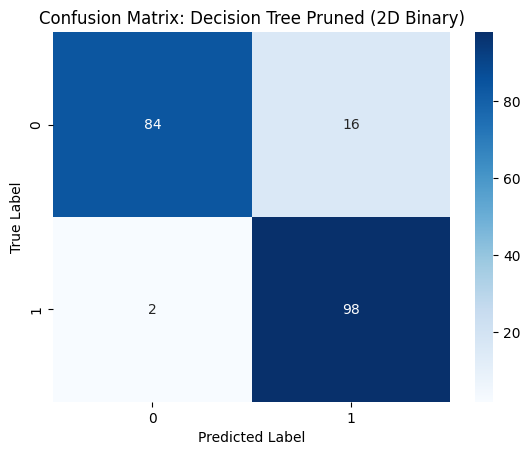

Saving figure confusion_matrix_dtree_pruned_2d_binary


<Figure size 640x480 with 0 Axes>

In [19]:
# Plotting Classifier Confusion Matrix
conf_matrix_dtree_pruned = confusion_matrix(y_2d_binary,y_pred_dtree_pruned)

sns.heatmap(conf_matrix_dtree_pruned, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Decision Tree Pruned (2D Binary)")
plt.show()
save_fig("confusion_matrix_dtree_pruned_2d_binary")

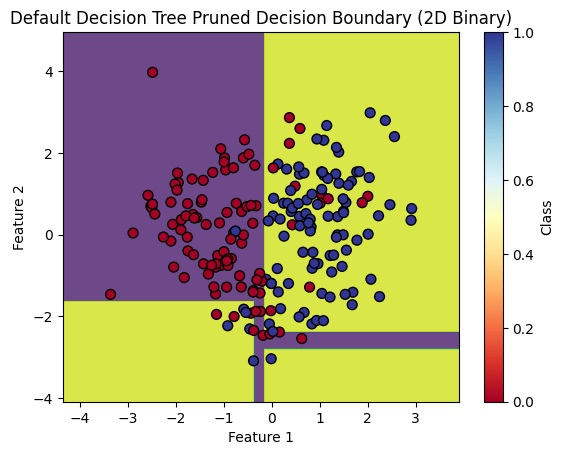

Saving figure decision_boundary_dtree_pruned_2d_binary


<Figure size 640x480 with 0 Axes>

In [20]:
# Call the decision boundary plotting function for the default Decision Tree model
plot_decision_boundary(dtree_pruned_model, X_2d_binary, y_2d_binary, title='Default Decision Tree Pruned Decision Boundary (2D Binary)')
save_fig("decision_boundary_dtree_pruned_2d_binary")

***Cost-complexity pruning (ccp)*** is a technique used to reduce the complexity of decision trees by trimming off parts of the tree that contribute little to the overall predictive accuracy. It adds a penalty term to the impurity measure (such as Gini impurity or entropy) to penalize the complexity of the tree. The penalty is controlled by a hyperparameter called alpha (ccp_alpha).

Here's how cost-complexity pruning works:

1. Train a decision tree on the training data.
2. Calculate the impurity (e.g., Gini impurity or entropy) of each node in the tree.
3. Calculate the total impurity of the tree by summing the impurities of all nodes.
4. Introduce a penalty term based on the number of nodes in the tree (tree complexity).
5. Adjust the penalty term using the hyperparameter alpha (ccp_alpha).
6. Select the subtree that minimizes the cost-complexity criterion (total impurity + penalty).
7. Repeat steps 4-6 for different values of alpha to create a sequence of subtrees.
8. Choose the optimal subtree based on cross-validation or another criterion.

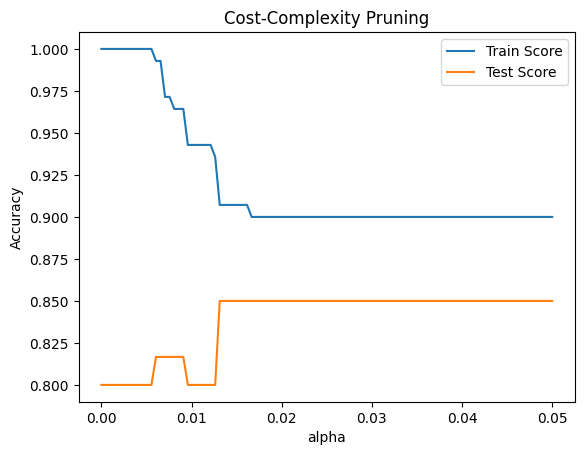

Saving figure cost_complexity_pruning


<Figure size 640x480 with 0 Axes>

In [21]:
# Cost-Complexity Pruning (CCP)
ccp_alphas = np.linspace(0, 0.05, 100)
trees_ccp = []
for ccp_alpha in ccp_alphas:
    tree = DecisionTreeClassifier(ccp_alpha=ccp_alpha, random_state=42)
    tree.fit(X_train, y_train)
    trees_ccp.append(tree)

train_scores_ccp = [tree.score(X_train, y_train) for tree in trees_ccp]
test_scores_ccp = [tree.score(X_test, y_test) for tree in trees_ccp]

fig = plt.figure()
fig.clf()

plt.plot(ccp_alphas,train_scores_ccp, label="Train Score")
plt.plot(ccp_alphas,test_scores_ccp, label="Test Score")
plt.xlabel("alpha")
plt.ylabel("Accuracy")
plt.title("Cost-Complexity Pruning")
plt.legend()
plt.show()
save_fig("cost_complexity_pruning")

In [22]:
best_ccp_index = np.argmax(test_scores_ccp)
best_ccp_alpha = ccp_alphas[best_ccp_index]
best_tree_ccp = trees_ccp[best_ccp_index]

# Visualizing Classifier Performance
y_pred_dtree_ccp = best_tree_ccp.predict(X_2d_binary)

print("Classification Report for Decision Tree Pruned (CCP):")
print(classification_report(y_2d_binary,y_pred_dtree_ccp))

Classification Report for Decision Tree Pruned (CCP):
              precision    recall  f1-score   support

           0       0.95      0.82      0.88       100
           1       0.84      0.96      0.90       100

    accuracy                           0.89       200
   macro avg       0.90      0.89      0.89       200
weighted avg       0.90      0.89      0.89       200



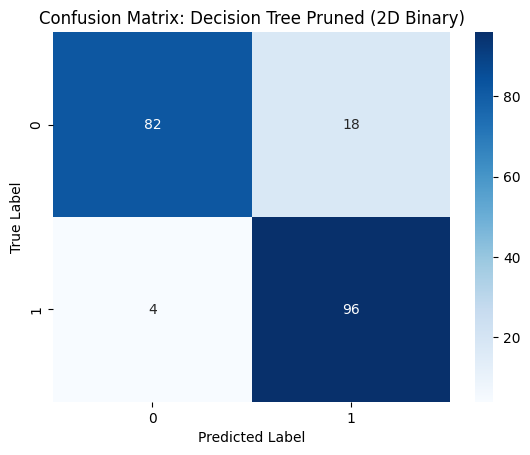

Saving figure confusion_matrix_dtree_ccp_2d_binary


<Figure size 640x480 with 0 Axes>

In [23]:
# Plotting Classifier Confusion Matrix
conf_matrix_dtree_ccp = confusion_matrix(y_2d_binary,y_pred_dtree_ccp)

sns.heatmap(conf_matrix_dtree_ccp, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Decision Tree Pruned (2D Binary)")
plt.show()
save_fig("confusion_matrix_dtree_ccp_2d_binary")

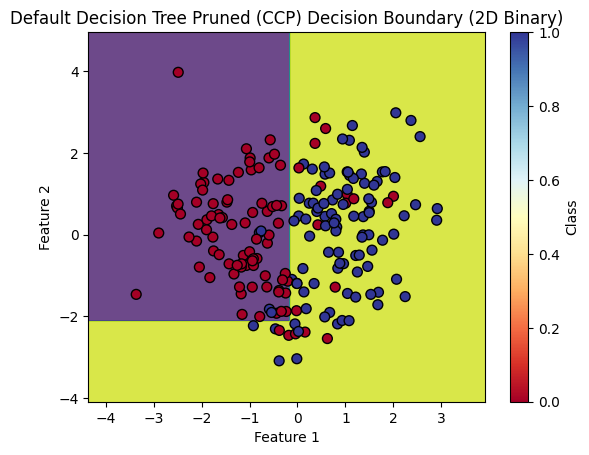

Saving figure decision_boundary_dtree_ccp_2d_binary


<Figure size 640x480 with 0 Axes>

In [24]:
# Call the decision boundary plotting function for the default Decision Tree model
plot_decision_boundary(best_tree_ccp, X_2d_binary, y_2d_binary, title='Default Decision Tree Pruned (CCP) Decision Boundary (2D Binary)')
save_fig("decision_boundary_dtree_ccp_2d_binary")

## Classifier: Random Forest

Random Forests are a powerful **ensemble learning** method built on top of Decision Trees. An ensemble method combines the predictions of several base estimators to improve generalization and robustness over a single estimator. In the case of Random Forests, the base estimators are Decision Trees.

1.  **How Random Forests Work (Ensemble Learning)**:
    *   **Bagging (Bootstrap Aggregating)**: Random Forests utilize a technique called bagging. It works by training multiple Decision Trees on different subsets of the training data. Each subset is created by **bootstrapping**, which means sampling with replacement from the original training dataset. This introduces randomness and ensures that each tree sees a slightly different version of the data.
    *   **Feature Randomness**: In addition to bagging, Random Forests also introduce randomness in the feature selection process. When splitting a node in a Decision Tree, instead of considering all available features, a Random Forest randomly selects a subset of features from which to choose the best split. This further decorrelates the individual trees.
    *   **Aggregation**: For classification tasks, the predictions from all individual trees are combined through a **majority vote**. The class that receives the most votes from the ensemble of trees is the final prediction.

2.  **Improvement over Individual Decision Trees (Bias-Variance Trade-off)**:
    *   **Individual Decision Trees**: A single, unconstrained Decision Tree is often prone to **overfitting** (high variance) because it can capture very intricate patterns in the training data, including noise. While it might have low bias (it can represent complex functions), its predictions can vary significantly with small changes in the training data.
    *   **Random Forests' Solution**: Random Forests mitigate this problem by combining many 'weak' learners (typically deep, unpruned Decision Trees that are prone to overfitting individually) into a 'strong' learner. Here's how it addresses the bias-variance trade-off:
        *   **Reducing Variance**: The primary benefit of Random Forests is the significant reduction in variance. By training trees on different bootstrapped samples and restricting feature consideration, individual trees are made to be somewhat different and independent. When their predictions are averaged (or voted upon), the errors and biases of individual trees tend to cancel each other out, leading to a much more stable and robust model. The variance of the ensemble is typically much lower than the variance of any single tree.
        *   **Maintaining Low Bias**: While reducing variance, Random Forests generally manage to maintain the low bias characteristics of deep Decision Trees. Each individual tree, being deep, can still learn complex relationships. The ensemble ensures that this complexity is not overfit to specific data points but generalized across the dataset.

    *   **Outcome**: The result is a model that is robust to noise, less prone to overfitting than a single Decision Tree, and generally achieves better generalization performance. The decision boundaries generated by Random Forests are often smoother and more complex than those of Logistic Regression, yet less jagged and prone to overfitting than an unpruned Decision Tree.

In [25]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate a RandomForestClassifier model and fit it
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_2d_binary, y_2d_binary)

print("Random Forest model fitted successfully.")

Random Forest model fitted successfully.


In [26]:
# Visualizing Classifier Performance
y_pred_rf = rf_model.predict(X_2d_binary)

print("Classification Report for Random Forest:")
print(classification_report(y_2d_binary,y_pred_rf))

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



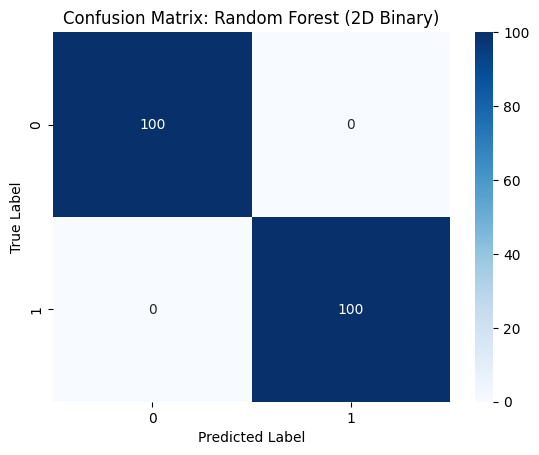

Saving figure confusion_matrix_rf_2d_binary


<Figure size 640x480 with 0 Axes>

In [27]:
# Plotting Classifier Confusion Matrix
conf_matrix_rf = confusion_matrix(y_2d_binary,y_pred_rf)

sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Random Forest (2D Binary)")
plt.show()
save_fig("confusion_matrix_rf_2d_binary")

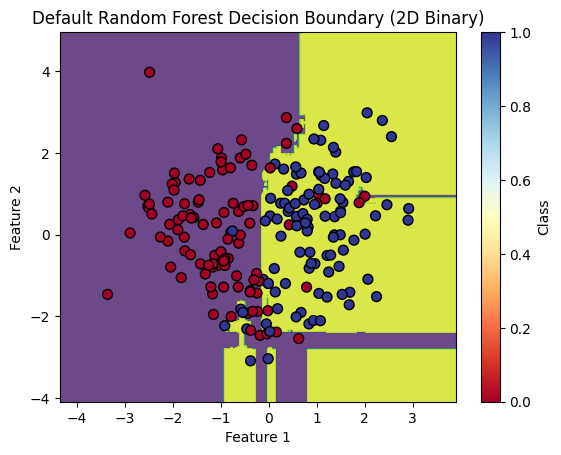

Saving figure decision_boundary_rf_2d_binary


<Figure size 640x480 with 0 Axes>

In [28]:
# Call the decision boundary plotting function for the default Decision Tree model
plot_decision_boundary(rf_model, X_2d_binary, y_2d_binary, title='Default Random Forest Decision Boundary (2D Binary)')
save_fig("decision_boundary_rf_2d_binary")

In [29]:
# Instantiate a second RandomForestClassifier with a limited max_depth (pruning)
rf_pruned_model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf_pruned_model.fit(X_2d_binary, y_2d_binary)

print("Pruned Random Forest model (max_depth=3) fitted successfully.")

Pruned Random Forest model (max_depth=3) fitted successfully.


In [30]:
# Visualizing Classifier Performance
y_pred_rf_pruned = rf_pruned_model.predict(X_2d_binary)

print("Classification Report for Random Forest Pruned:")
print(classification_report(y_2d_binary,y_pred_rf_pruned))

Classification Report for Random Forest Pruned:
              precision    recall  f1-score   support

           0       0.96      0.87      0.91       100
           1       0.88      0.96      0.92       100

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.91       200
weighted avg       0.92      0.92      0.91       200



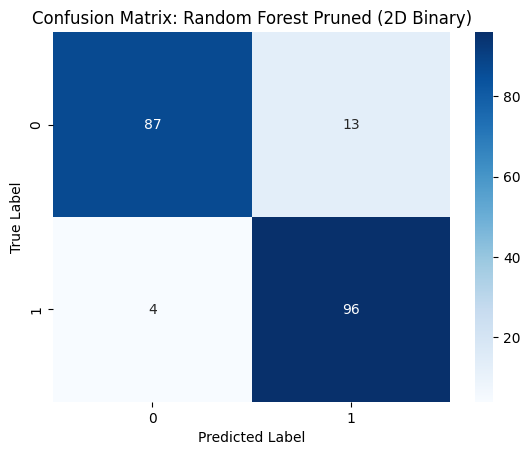

Saving figure confusion_matrix_rf_pruned_2d_binary


<Figure size 640x480 with 0 Axes>

In [31]:
# Plotting Classifier Confusion Matrix
conf_matrix_rf_pruned = confusion_matrix(y_2d_binary,y_pred_rf_pruned)

sns.heatmap(conf_matrix_rf_pruned, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Random Forest Pruned (2D Binary)")
plt.show()
save_fig("confusion_matrix_rf_pruned_2d_binary")

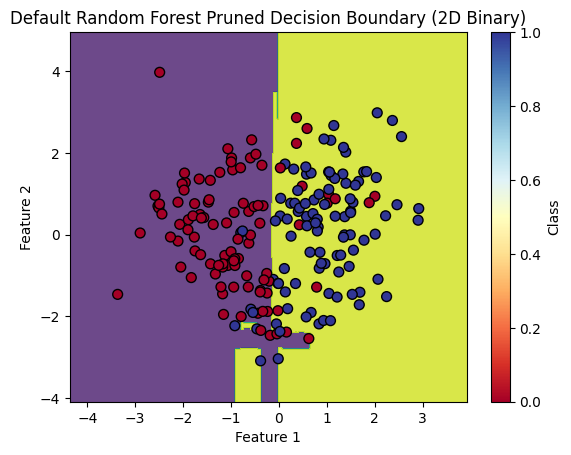

Saving figure decision_boundary_rf_pruned_2d_binary


<Figure size 640x480 with 0 Axes>

In [32]:
# Call the decision boundary plotting function for the default Decision Tree model
plot_decision_boundary(rf_pruned_model, X_2d_binary, y_2d_binary, title='Default Random Forest Pruned Decision Boundary (2D Binary)')
save_fig("decision_boundary_rf_pruned_2d_binary")

## Comparative Decision Boundaries (2D Binary)

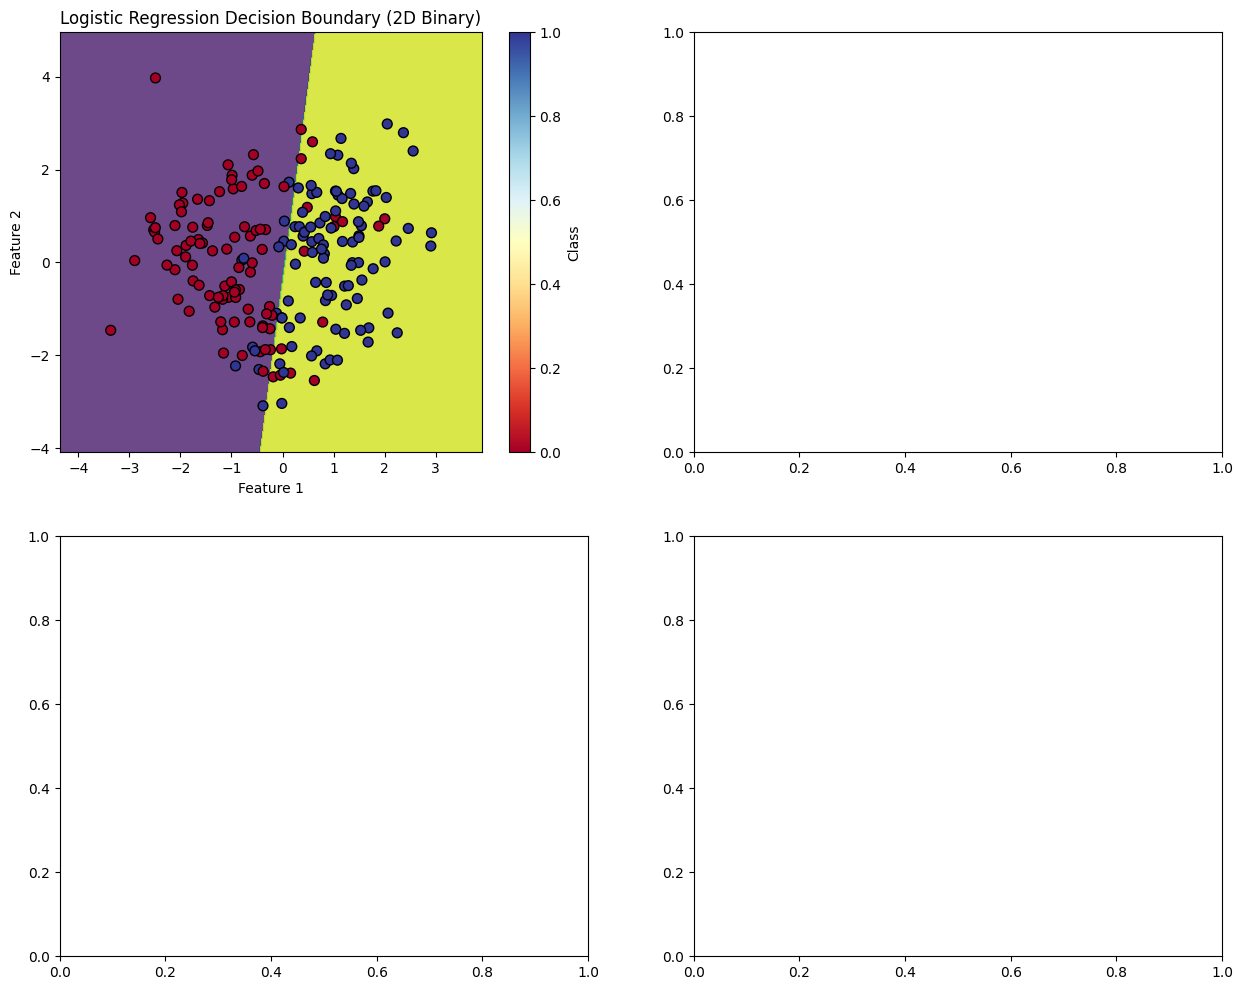

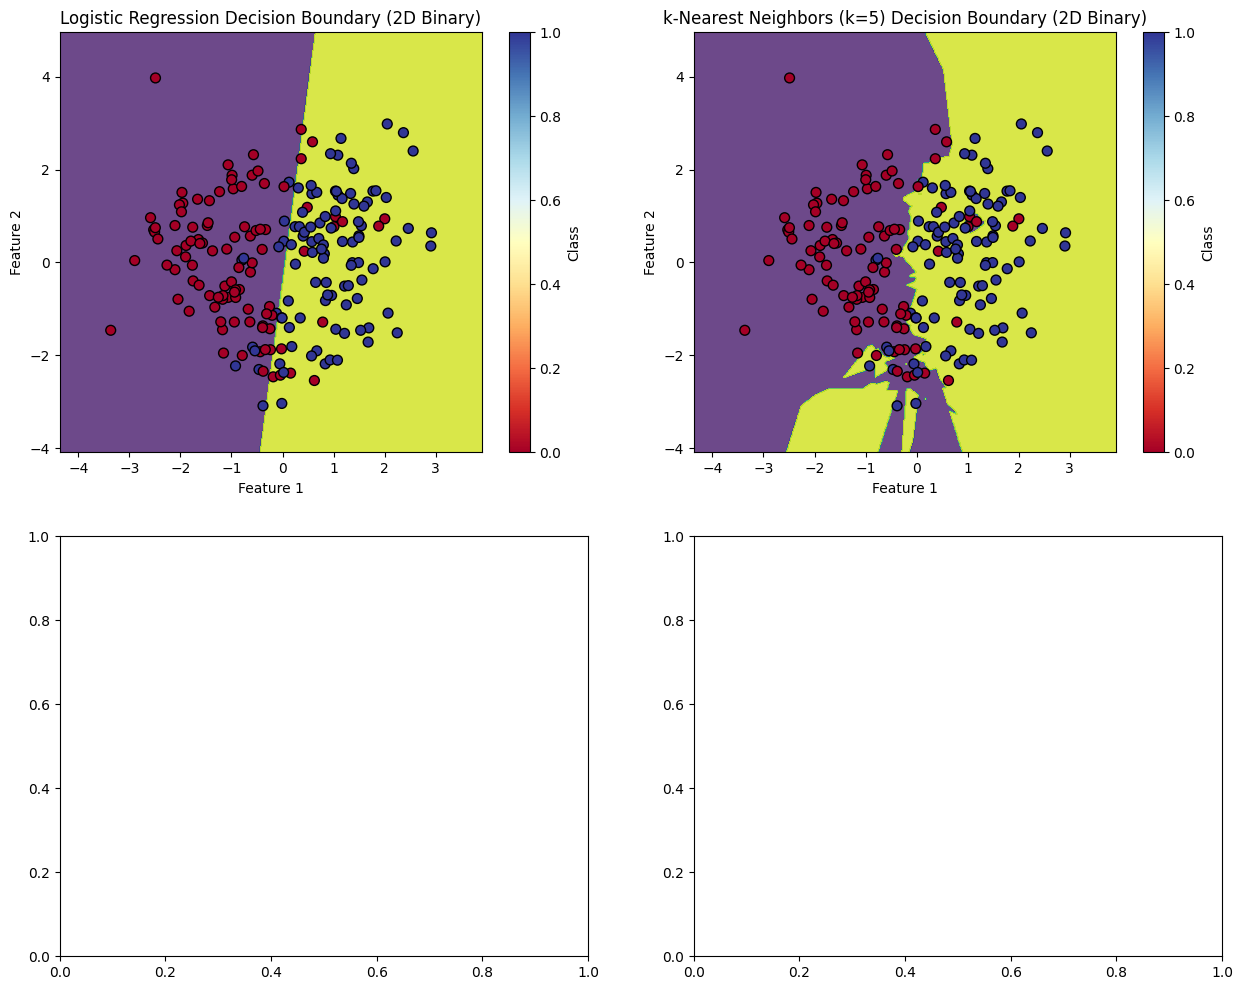

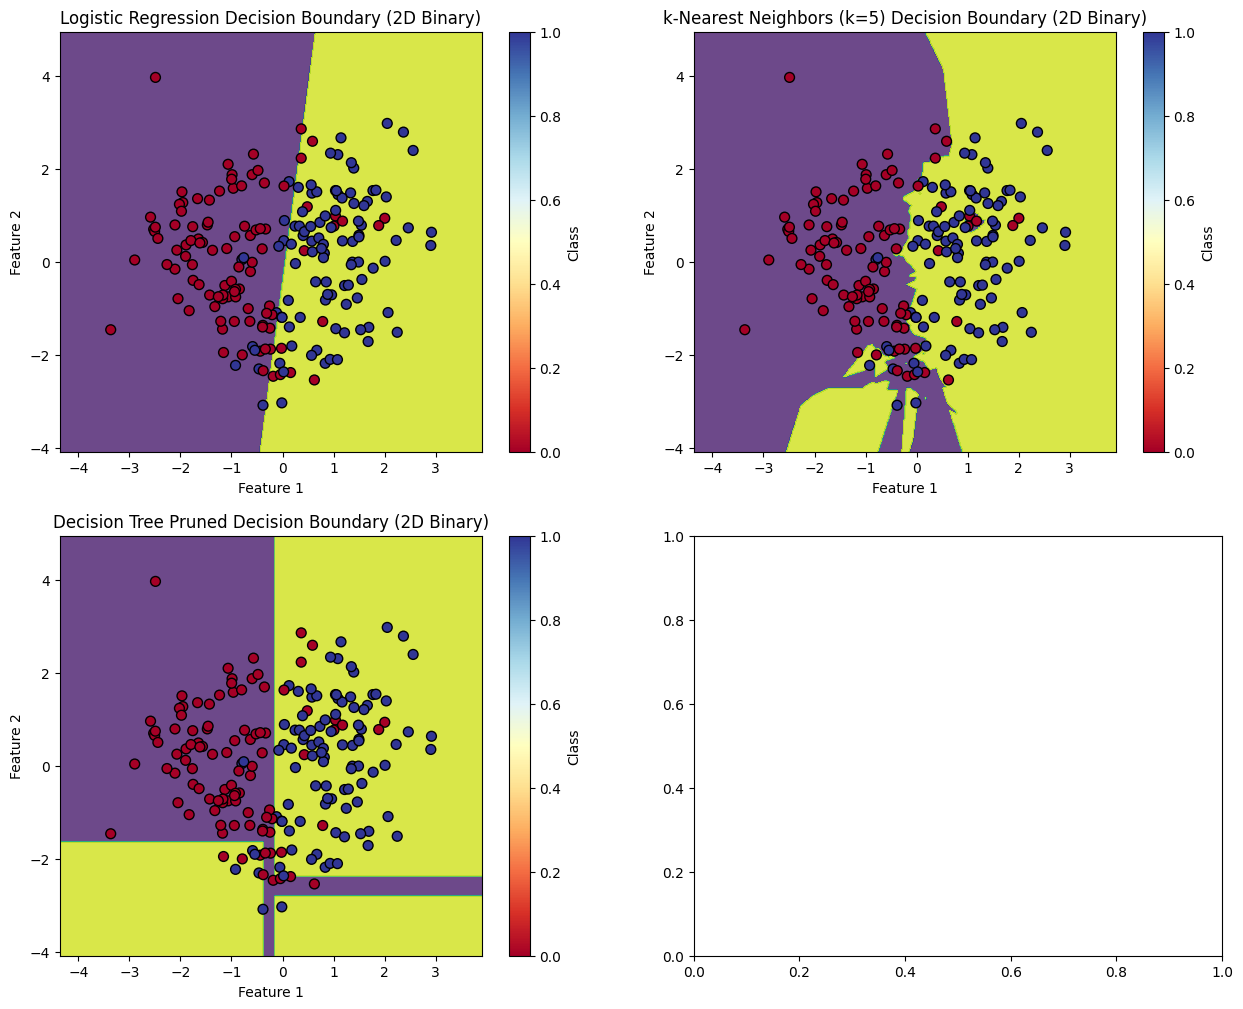

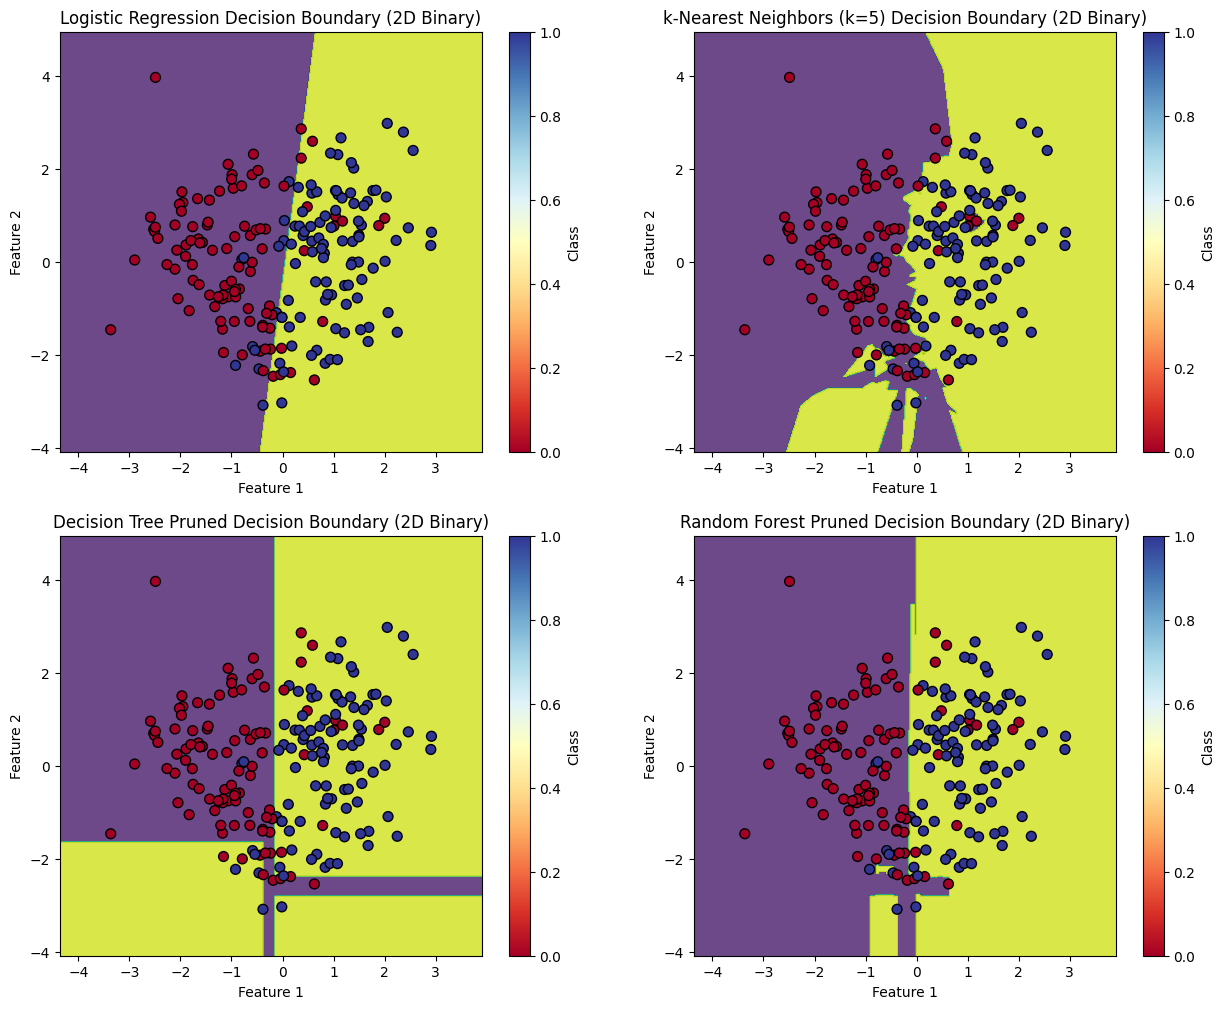

<Figure size 640x480 with 0 Axes>

Saving figure comaparison_db_plot_2d_binary


<Figure size 640x480 with 0 Axes>

In [33]:
# Prepare the models for comparison
models = {
    'Logistic Regression': log_reg_model,
    'k-Nearest Neighbors (k=5)': knn_model,
    'Decision Tree Pruned': dtree_pruned_model,
    'Random Forest Pruned': rf_pruned_model
}

# Create a figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

# Iterate through models and plot their decision boundaries
for i, (name, model) in enumerate(models.items()):
    plt.sca(axes[i]) # Set the current axes for plotting
    plot_decision_boundary(model, X_2d_binary, y_2d_binary, title=f'{name} Decision Boundary (2D Binary)')

# Adjust layout to prevent overlaps and ensure readability
plt.tight_layout()
plt.suptitle('Comparison of Decision Boundaries (2D Binary Classification)', y=1.02, fontsize=16)
plt.show()
save_fig('comaparison_db_plot_2d_binary')

## 2D Multiclass Classification

Non-parametric models inherently adapt to multiclass classification scenarios without significant changes to their core algorithms, primarily by extending their decision-making processes to more than two classes.

1.  **k-Nearest Neighbors (kNN)**:
    *   **Mechanism**: For a given new data point, kNN identifies its `k` nearest neighbors from the training data, regardless of the number of classes. Once these neighbors are identified, the classification decision is made by a **majority vote** among the classes of these `k` neighbors. The new data point is assigned to the class that is most represented among its neighbors.
    *   **Adaptation**: This approach is naturally multiclass. There's no need for a 'one-vs-rest' or 'one-vs-one' strategy; the voting mechanism simply counts occurrences of all classes among the neighbors and picks the most frequent one.

2.  **Decision Trees**:
    *   **Mechanism**: Decision Trees intrinsically support multiclass classification. During the tree building process, at each node, the impurity (e.g., Gini impurity or entropy) is calculated based on the distribution of *all* classes within that node. The splitting criterion seeks to maximize the information gain or reduce impurity with respect to all classes.
    *   **Adaptation**: Each leaf node in a Decision Tree will represent a region in the feature space that primarily contains samples of a single class (or a majority class, if the node is not perfectly pure). When a new data point reaches a leaf node, it is directly assigned the class label of that leaf node, which is determined by the majority class of the training samples within that leaf.

3.  **Random Forests**:
    *   **Mechanism**: As an ensemble of Decision Trees, Random Forests extend the multiclass capability of individual trees. Each tree in the forest is trained on a bootstrapped subset of the data and makes its own prediction for a new data point, based on its internal multiclass decision logic (as described for single Decision Trees).
    *   **Adaptation**: For the final prediction, Random Forests aggregate the predictions from all the individual trees. In a multiclass scenario, this typically involves a **majority vote** across all trees. Each tree 'votes' for a specific class, and the class that receives the most votes across the entire forest is chosen as the final classification. This ensemble approach generally leads to more robust and accurate multiclass predictions compared to a single Decision Tree.

In [34]:
# Generate a synthetic 2D multiclass classification dataset
X_2d_multiclass, y_2d_multiclass = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=3, # 3 classes for multiclass
    n_clusters_per_class=1,
    random_state=42
)


Calculated accuracies for k from 3 to 29.


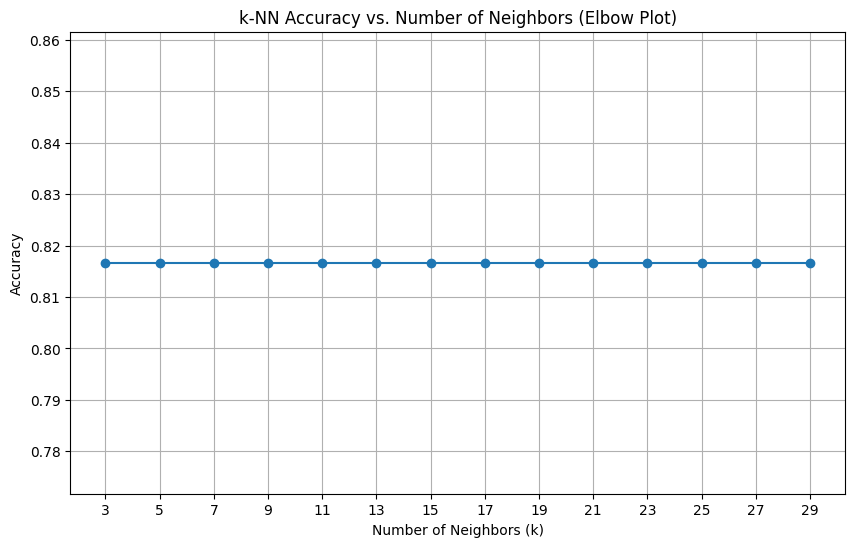

Saving figure elbow_plot_knn_2d_multiclass


<Figure size 640x480 with 0 Axes>

In [35]:
# Split the X_2d_multiclass and y_2d_multiclass data into training and testing sets
X_train_multiclass, X_test_multiclass, y_train_multiclass, y_test_multiclass = train_test_split(X_2d_multiclass, y_2d_multiclass, test_size=0.3, random_state=42)

accuracies_multiclass = []
k_range = range(3, 31, 2) # Iterate k from 3 to 30

for k in k_range:
    # Instantiate a KNeighborsClassifier model with the current k value
    knn_k_model_multiclass = KNeighborsClassifier(n_neighbors=k)

    # Train this model on the training data
    knn_k_model_multiclass.fit(X_train_multiclass, y_train_multiclass)

    # Predict on the test data
    y_pred_multiclass = knn_k_model_multiclass.predict(X_test_multiclass)

    # Calculate the accuracy score on the predictions
    accuracy_multiclass = accuracy_score(y_test_multiclass, y_pred_multiclass)

    # Store the accuracy
    accuracies_multiclass.append(accuracy)

print(f"Calculated accuracies for k from 3 to {max(k_range)}.")

# Plot the calculated accuracy scores against their respective k values
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies_multiclass, marker='o', linestyle='-')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('k-NN Accuracy vs. Number of Neighbors (Elbow Plot)')
plt.xticks(list(k_range))
plt.grid(True)
plt.show()
save_fig("elbow_plot_knn_2d_multiclass")

In [36]:
# Initialize and fit a KNeighborsClassifier model for multiclass
knn_multiclass_model = KNeighborsClassifier(n_neighbors=5)
knn_multiclass_model.fit(X_2d_multiclass, y_2d_multiclass)

print("k-Nearest Neighbors model (k=5) for 2D Multiclass fitted successfully.")

k-Nearest Neighbors model (k=5) for 2D Multiclass fitted successfully.


In [37]:
print("Classification Report for kNN Multiclass:")
print(classification_report(y_2d_multiclass,knn_multiclass_model.predict(X_2d_multiclass)))

Classification Report for kNN Multiclass:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80        67
           1       0.90      0.84      0.87        67
           2       0.87      0.92      0.90        66

    accuracy                           0.85       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.86      0.85      0.85       200



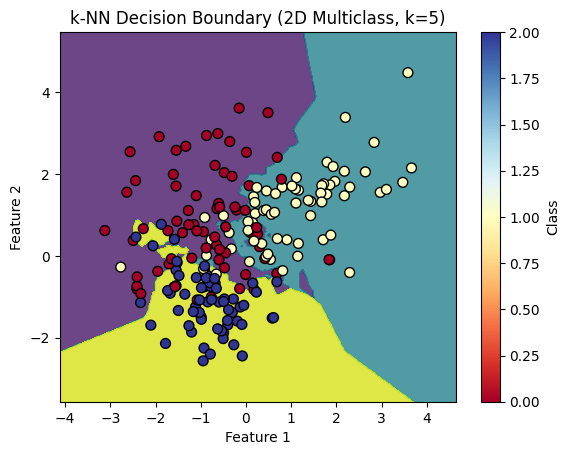

Saving figure decision_boundary_knn_multiclass_2d


<Figure size 640x480 with 0 Axes>

In [38]:
# Visualize the decision boundary of the kNN model for 2D multiclass
plot_decision_boundary(knn_multiclass_model, X_2d_multiclass, y_2d_multiclass, title='k-NN Decision Boundary (2D Multiclass, k=5)')
save_fig("decision_boundary_knn_multiclass_2d")

In [39]:
# Initialize and fit a DecisionTreeClassifier model for multiclass
dtree_multiclass_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dtree_multiclass_model.fit(X_2d_multiclass, y_2d_multiclass)

print("Decision Tree Pruned model (max_depth=3) for 2D Multiclass fitted successfully.")

Decision Tree Pruned model (max_depth=3) for 2D Multiclass fitted successfully.


In [40]:
print("Classification Report for Decision Tree Pruned Multiclass:")
print(classification_report(y_2d_multiclass,dtree_multiclass_model.predict(X_2d_multiclass)))

Classification Report for Decision Tree Pruned Multiclass:
              precision    recall  f1-score   support

           0       0.74      0.76      0.75        67
           1       0.84      0.87      0.85        67
           2       0.92      0.86      0.89        66

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200



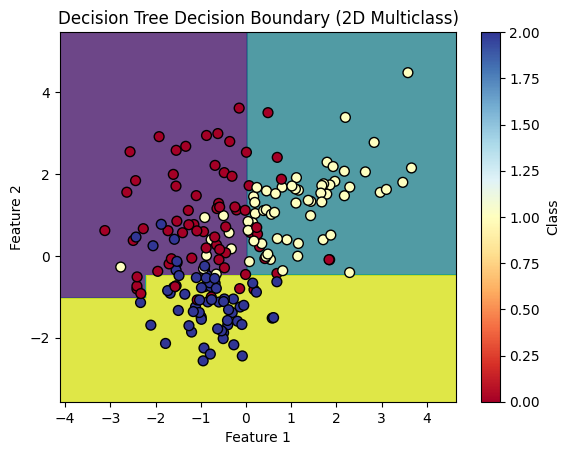

Saving figure decision_boundary_dtree_multiclass_2d


<Figure size 640x480 with 0 Axes>

In [41]:
# Visualize the decision boundary of the Decision Tree model for 2D multiclass
plot_decision_boundary(dtree_multiclass_model, X_2d_multiclass, y_2d_multiclass, title='Decision Tree Decision Boundary (2D Multiclass)')
save_fig("decision_boundary_dtree_multiclass_2d")

In [42]:
# Initialize and fit a RandomForestClassifier model for multiclass
rf_multiclass_model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf_multiclass_model.fit(X_2d_multiclass, y_2d_multiclass)

print("Random Forest Pruned model (max_depth=3) for 2D Multiclass fitted successfully.")

Random Forest Pruned model (max_depth=3) for 2D Multiclass fitted successfully.


In [43]:
print("Classification Report for Random Forest Pruned Multiclass:")
print(classification_report(y_2d_multiclass,rf_multiclass_model.predict(X_2d_multiclass)))

Classification Report for Random Forest Pruned Multiclass:
              precision    recall  f1-score   support

           0       0.77      0.76      0.77        67
           1       0.84      0.87      0.85        67
           2       0.91      0.89      0.90        66

    accuracy                           0.84       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.84      0.84      0.84       200



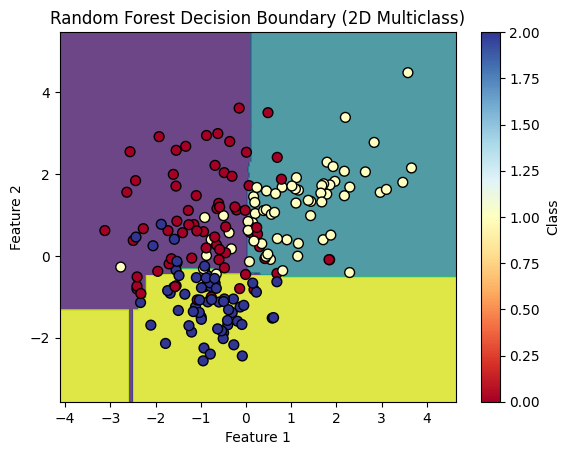

Saving figure decision_boundary_rf_multiclass_2d


<Figure size 640x480 with 0 Axes>

In [44]:
# Visualize the decision boundary of the Random Forest model for 2D multiclass
plot_decision_boundary(rf_multiclass_model, X_2d_multiclass, y_2d_multiclass, title='Random Forest Decision Boundary (2D Multiclass)')
save_fig("decision_boundary_rf_multiclass_2d")

## N-Feature Binary Classification

**Principal Component Analysis (PCA) Explained**

Principal Component Analysis (PCA) is a powerful, unsupervised dimensionality reduction technique widely used in machine learning and data analysis. Its primary goal is to transform a dataset with many features into a new dataset with fewer features (principal components) while retaining as much of the original variance as possible.

1.  **Purpose of PCA**:
    *   **Dimensionality Reduction**: The most common application is to reduce the number of features in a dataset, which can help in handling the "curse of dimensionality." This leads to faster training times for models and can mitigate overfitting by reducing noise.
    *   **Noise Reduction**: By focusing on the components with the highest variance, PCA can effectively filter out noise present in less significant dimensions.
    *   **Visualization**: For high-dimensional data (more than 3 features), direct visualization is impossible. PCA allows us to project this data onto a lower-dimensional space (typically 2 or 3 dimensions) that captures most of the data's structure, making it visualizable and interpretable.
    *   **Feature Extraction**: PCA transforms the original features into a new set of orthogonal (uncorrelated) features, called principal components.

2.  **Mechanism of PCA**:
    PCA works by identifying the directions (vectors) in the feature space along which the data varies the most. These directions are called principal components. The process involves the following steps:

    *   **Standardization (Optional but Recommended)**: PCA is sensitive to the scale of the features. It's often recommended to standardize the data (mean of 0, standard deviation of 1) before applying PCA to ensure that features with larger scales don't dominate the components.

    *   **Covariance Matrix Computation**: PCA computes the covariance matrix of the original data. The covariance matrix summarizes how each feature varies with respect to every other feature.

    *   **Eigenvalue Decomposition**: The core of PCA involves performing an eigenvector decomposition on the covariance matrix. This decomposition yields two key results:
        *   **Eigenvectors**: These represent the principal components (the new axes). Each eigenvector points in a direction of high variance in the data. They are orthogonal to each other.
        *   **Eigenvalues**: Each eigenvalue corresponds to an eigenvector and indicates the amount of variance captured along that principal component. A larger eigenvalue means its corresponding eigenvector captures more variance.

    *   **Selecting Principal Components**: The principal components are ranked by their corresponding eigenvalues in descending order. We then select the top `k` principal components (eigenvectors) that capture a sufficient amount of the total variance (e.g., 95% or as specified by `n_components`). In our case, `n_components=2` means we are selecting the two principal components that explain the most variance.

    *   **Projection (Transformation)**: Finally, the original `n`-dimensional data is projected onto the new `k`-dimensional subspace defined by the selected `k` principal components. This creates a new dataset where each data point is represented by its coordinates along these new axes. This `X_pca_2d` dataset now contains the original information condensed into 2 dimensions, suitable for plotting.

## Non-Parametric Models with PCA Visualization (10-Feature)

Visualizing decision boundaries in a 2D PCA-reduced space for models trained on high-dimensional data provides a simplified, yet insightful, view of the model's behavior. However, it's crucial to understand the implications of this reduction:

1.  **Approximation, Not Exact Representation**: The 2D PCA plot is a projection of the original 10-dimensional data onto the two principal components that capture the most variance. While it preserves the most significant structure, it is still an approximation. The decision boundary we observe in this 2D space is the *projection* of the true high-dimensional decision boundary.

2.  **Linearity in Reduced Space vs. Original Space**: A decision boundary that appears linear or relatively simple in the 2D PCA space **does not necessarily mean** the decision boundary in the original 10-dimensional space is linear. Due to the non-linear nature of many non-parametric models, a linear separation in the original high-dimensional space could project as a complex, non-linear boundary in the reduced PCA space, and vice-versa.
    *   For instance, a simple hyperplane (linear decision boundary) in a 10D space might look like a curvy line when projected onto a 2D plane if the plane is not aligned with the hyperplane.
    *   Conversely, a complex, non-linear boundary in 10D might appear simpler if its most defining features align with the principal components.

3.  **Model Behavior in Original Space**: The models (kNN, Decision Tree, Random Forest) were trained on the *original 10-feature dataset*. Their decision-making process inherently operates in that 10-dimensional space. The `plot_decision_boundary_pca` function cleverly demonstrates this: it takes points from the 2D PCA meshgrid, inverse-transforms them back into the 10D space, and then asks the 10D-trained model for a prediction. This prediction is then plotted back in the 2D PCA space.

4.  **Insights from PCA-reduced Boundaries**:
    *   **Separability**: Even with dimensionality reduction, if the classes appear well-separated in the PCA plot, it suggests good separability in the original space. Conversely, if classes are heavily overlapping, the model will likely struggle even in higher dimensions.
    *   **Model Complexity**: We can still observe relative complexities. A kNN model's boundary might still appear more intricate than a Logistic Regression (if it were shown) or a heavily pruned Decision Tree. Random Forests tend to produce smoother, yet still complex, boundaries compared to single Decision Trees, reflecting their ensemble nature.
    *   **Understanding Feature Contribution**: While PCA doesn't directly give us decision rules based on original features, by understanding which original features contribute most to the principal components, we can gain some intuition about the underlying data structure that the models are leveraging.

In summary, PCA-based visualization provides a valuable simplification that helps in understanding the general separability of classes and the relative complexity of decision boundaries generated by different models, but it's important to remember that it's a projection and not the full, intricate decision space of the high-dimensional model.

In [45]:
# Generate a synthetic 10-feature binary classification dataset
X_10d_binary, y_10d_binary = make_classification(
    n_samples=200,
    n_features=10,
    n_informative=8,
    n_redundant=2,
    n_classes=2, # Binary classification
    n_clusters_per_class=2,
    random_state=42
)

Calculated accuracies for k from 3 to 29.


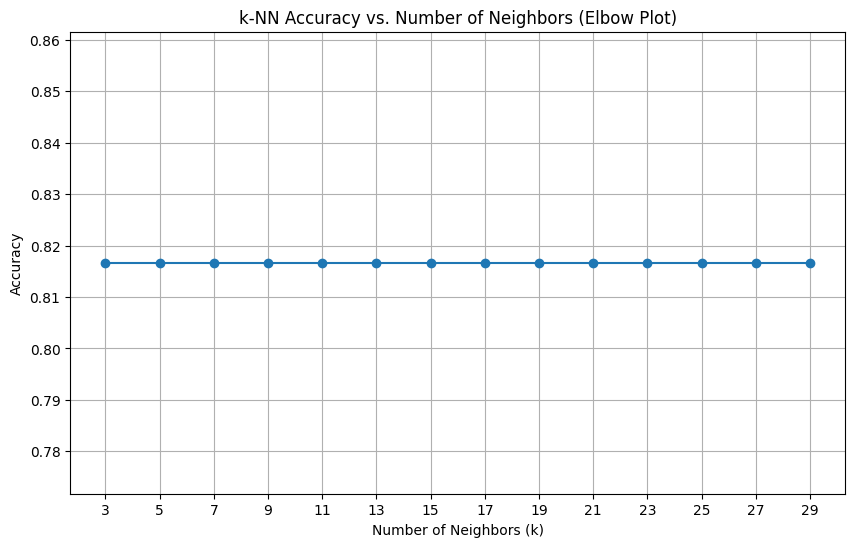

Saving figure elbow_plot_knn_10d


<Figure size 640x480 with 0 Axes>

In [46]:
# Split the X_10d_binary and y_10d_binary data into training and testing sets
X_train_10d, X_test_10d, y_train_10d, y_test_10d = train_test_split(X_10d_binary, y_10d_binary, test_size=0.3, random_state=42)

accuracies_10d = []
k_range = range(3, 31, 2) # Iterate k from 3 to 30

for k in k_range:
    # Instantiate a KNeighborsClassifier model with the current k value
    knn_k_model_10d = KNeighborsClassifier(n_neighbors=k)

    # Train this model on the training data
    knn_k_model_10d.fit(X_train_10d, y_train_10d)

    # Predict on the test data
    y_pred_10d = knn_k_model_10d.predict(X_test_10d)

    # Calculate the accuracy score on the predictions
    accuracy_10d = accuracy_score(y_test_10d, y_pred_10d)

    # Store the accuracy
    accuracies_10d.append(accuracy)

print(f"Calculated accuracies for k from 3 to {max(k_range)}.")

# Plot the calculated accuracy scores against their respective k values
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies_10d, marker='o', linestyle='-')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('k-NN Accuracy vs. Number of Neighbors (Elbow Plot)')
plt.xticks(list(k_range))
plt.grid(True)
plt.show()
save_fig("elbow_plot_knn_10d")

In [47]:
# Initialize and fit a KNeighborsClassifier model for multiclass
knn_10d_model = KNeighborsClassifier(n_neighbors=5)
knn_10d_model.fit(X_10d_binary, y_10d_binary)

print("k-Nearest Neighbors model (k=5) for 10D binary fitted successfully.")

k-Nearest Neighbors model (k=5) for 10D binary fitted successfully.


In [48]:
print("Classification Report for kNN 10D:")
print(classification_report(y_10d_binary,knn_10d_model.predict(X_10d_binary)))

Classification Report for kNN 10D:
              precision    recall  f1-score   support

           0       0.89      0.88      0.89       102
           1       0.88      0.89      0.88        98

    accuracy                           0.89       200
   macro avg       0.88      0.89      0.88       200
weighted avg       0.89      0.89      0.89       200



In [49]:
# Initialize and fit a DecisionTreeClassifier model for multiclass
dtree_10d_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dtree_10d_model.fit(X_10d_binary, y_10d_binary)

print("Decision Tree Pruned model (max_depth=3) for 10D binary fitted successfully.")

Decision Tree Pruned model (max_depth=3) for 10D binary fitted successfully.


In [50]:
print("Classification Report for Decision Tree Pruned 10D:")
print(classification_report(y_10d_binary,dtree_10d_model.predict(X_10d_binary)))

Classification Report for Decision Tree Pruned 10D:
              precision    recall  f1-score   support

           0       0.84      0.69      0.76       102
           1       0.73      0.87      0.79        98

    accuracy                           0.78       200
   macro avg       0.78      0.78      0.77       200
weighted avg       0.79      0.78      0.77       200



In [51]:
# Initialize and fit a RandomForestClassifier model for multiclass
rf_10d_model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf_10d_model.fit(X_10d_binary, y_10d_binary)

print("Random Forest Pruned model (max_depth=3) for 10D binary fitted successfully.")

Random Forest Pruned model (max_depth=3) for 10D binary fitted successfully.


In [52]:
print("Classification Report for Random Forest Pruned 10D:")
print(classification_report(y_10d_binary,rf_10d_model.predict(X_10d_binary)))

Classification Report for Random Forest Pruned 10D:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       102
           1       0.85      0.83      0.84        98

    accuracy                           0.84       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.85      0.84      0.84       200



In [53]:
from sklearn.decomposition import PCA

# Instantiate PCA with n_components=2
pca = PCA(n_components=2, random_state=42)

# Fit PCA to the 10-feature dataset and transform it
X_pca_2d = pca.fit_transform(X_10d_binary)

In [54]:
# Defining a new function, plot_decision_boundary_pca
def plot_decision_boundary_pca(model, pca_transformer, X_pca_2d_data, y_true, title="Decision Boundary with PCA"):
    # a. Determine min and max values for the first and second principal components
    x_min, x_max = X_pca_2d_data[:, 0].min() - 1, X_pca_2d_data[:, 0].max() + 1
    y_min, y_max = X_pca_2d_data[:, 1].min() - 1, X_pca_2d_data[:, 1].max() + 1
    h = 0.05  # step size in the mesh for smoother contours

    # b. Generate a 2D meshgrid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # c. Combine meshgrid points into a 2D array
    meshgrid_2d = np.c_[xx.ravel(), yy.ravel()]

    # d. Use pca_transformer.inverse_transform() to project these 2D meshgrid points back to original 10-feature space
    meshgrid_10d = pca_transformer.inverse_transform(meshgrid_2d)

    # e. Use the high-dimensional model.predict() to get class predictions
    Z = model.predict(meshgrid_10d)

    # f. Reshape the predictions to match the shape of xx
    Z = Z.reshape(xx.shape)

    # g. Plot the decision boundary contours
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)

    # h. Plot the original X_pca_2d_data points
    plt.scatter(X_pca_2d_data[:, 0], X_pca_2d_data[:, 1], c=y_true, edgecolors='k', marker='o', s=50, cmap=plt.cm.RdYlBu)

    # i. Add labels, title, and colorbar
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title(title)
    plt.colorbar(label='Class')
    plt.grid(True)
    plt.show()

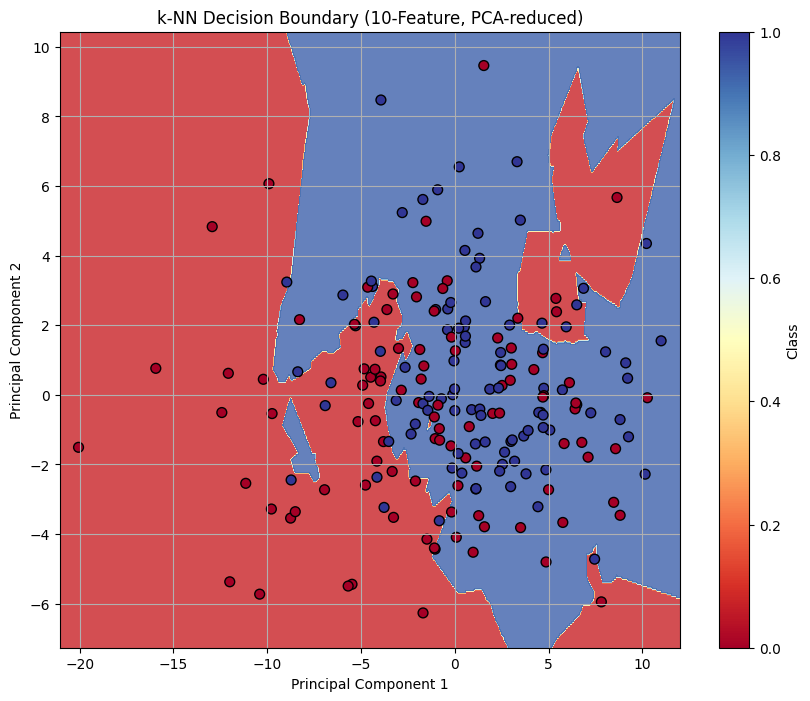

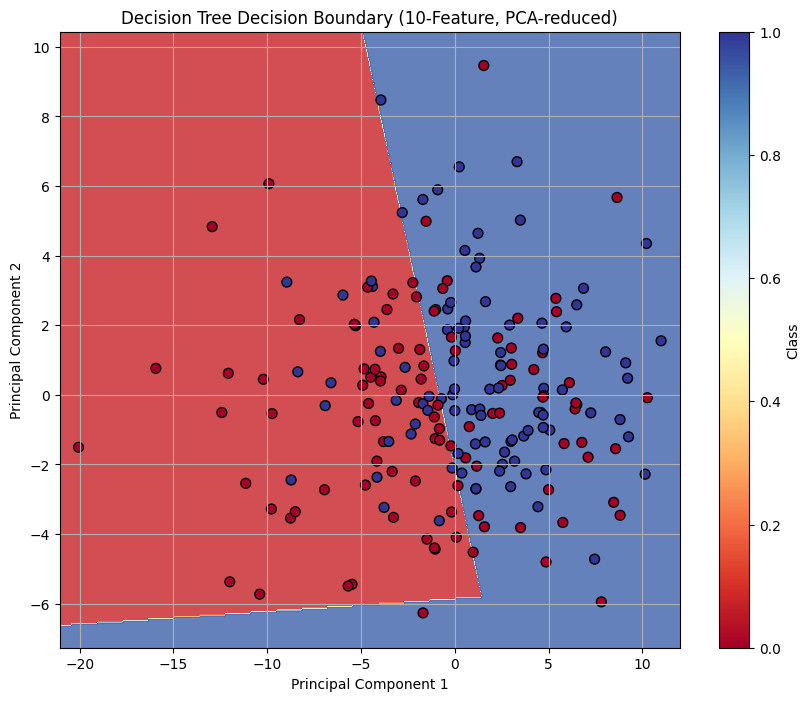

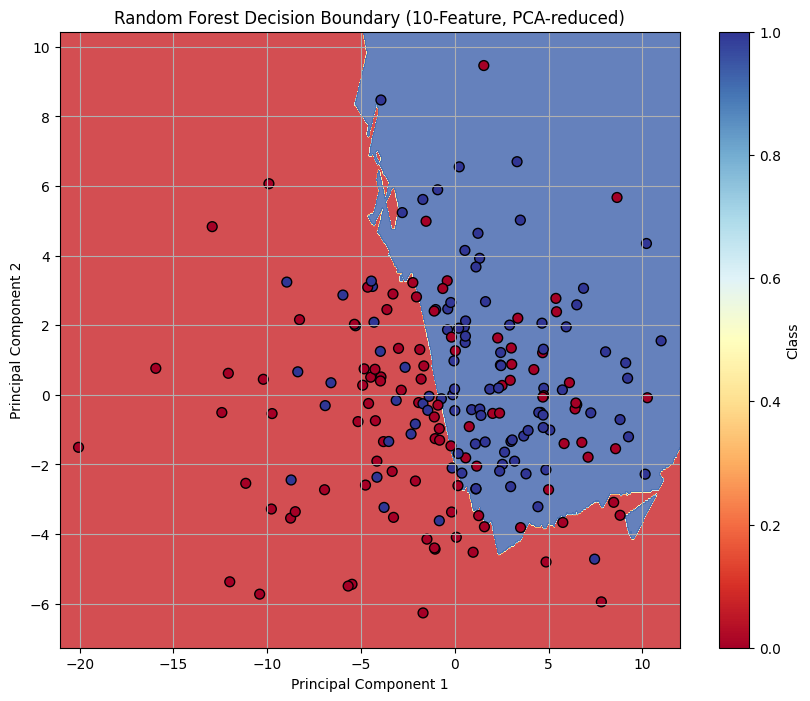

In [55]:
# Call the plot_decision_boundary_pca function for each model
plot_decision_boundary_pca(knn_10d_model, pca, X_pca_2d, y_10d_binary, title='k-NN Decision Boundary (10-Feature, PCA-reduced)')
plot_decision_boundary_pca(dtree_10d_model, pca, X_pca_2d, y_10d_binary, title='Decision Tree Decision Boundary (10-Feature, PCA-reduced)')
plot_decision_boundary_pca(rf_10d_model, pca, X_pca_2d, y_10d_binary, title='Random Forest Decision Boundary (10-Feature, PCA-reduced)')